# Machine Learning — Week 1 Notebook
### Your first hands-on ML notebook (Days 1-4 topics)

This notebook is yours to run, edit, break, and re-run. Every code cell has line-by-line comments explaining **why** that line exists, not just what it does. Read the markdown cell above each code block before running it.

**Dataset used:** Spotify Tracks Dataset (audio features + popularity for ~114,000 tracks)

**Dataset source link:** https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
Open that link on Kaggle -> click **New Notebook** (or open this notebook and click **Add Input** -> search `Spotify Tracks Dataset` by maharshipandya -> Add). Do this BEFORE running any cell below.

**Full roadmap & how each day works:** this is Week 1 of a 24-day, algorithm-first ML roadmap. Concepts and math are introduced only where the algorithm actually needs them. Each day builds on the previous one — miss a day's core idea and the next day gets harder, so re-run this notebook if anything feels shaky.

## 0. Kaggle environment setup — no Google Drive needed

On Colab you're used to `drive.mount('/content/drive')` and manually uploading/downloading files. **Kaggle works differently:**
- Click **Add Input** (top-right of the notebook) → search for a dataset → it attaches directly.
- The dataset then lives at `/kaggle/input/<dataset-folder-name>/` — permanently, no re-uploading every session.
- A free **T4 GPU** is available under **Settings → Accelerator** if you ever need it (not required for today).

Run the cell below — it walks through every file Kaggle has attached to this notebook, so you can see the exact path to use in `pd.read_csv()`.

In [1]:
import os
# os.walk() goes through every folder and file inside '/kaggle/input'
# dirname = current folder being looked at, filenames = list of files in it
dataset_paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # os.path.join builds the full file path correctly (handles the '/' for you)
        full_path = os.path.join(dirname, filename)
        print(full_path)
        if filename.endswith('.csv'):
            dataset_paths.append(full_path)

# If nothing printed above: click 'Add Input' (top-right) and attach the
# Spotify Tracks Dataset before running the next cells.

/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv


## 1. Environment & core libraries

**Python, Jupyter, virtual env — quick recap:** Python is the language, Jupyter is the notebook interface running Python cell-by-cell (what you're using right now), and a virtual environment is an isolated set of installed packages so one project's libraries don't clash with another's. Kaggle gives you a ready-made environment — no setup needed.

**What each library actually does — know this before writing a single line of data code:**

| Library | What it holds / does |
|---|---|
| **NumPy** | Fast numerical arrays and math operations — arrays, indexing/slicing, reshaping, broadcasting, aggregations (mean, sum, std). Almost every other library is built on top of NumPy arrays. |
| **Pandas** | Tabular data handling — reading CSV/Excel files into a table (DataFrame), filtering rows, selecting columns, grouping, merging tables together. Think "Excel, but programmable." |
| **Matplotlib** | The base plotting library — line charts, scatter plots, bar charts, histograms, multiple subplots in one figure. |
| **Seaborn** | Built ON TOP of Matplotlib — makes statistical plots (distributions, box plots, pair plots, correlation heatmaps) with much less code and better default styling. |
| **scikit-learn** | The ML toolbox — preprocessing tools (scalers, encoders), and the actual ML algorithms (regression, classification, clustering) we'll use starting Day 6. |

In [2]:
import numpy as np              # numerical arrays & math -> aliased as 'np' by convention
import pandas as pd             # tabular data (DataFrames) -> aliased as 'pd' by convention
import matplotlib.pyplot as plt # base plotting -> 'plt' is the standard alias
import seaborn as sns           # statistical plots built on matplotlib -> 'sns' is the standard alias
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
# StandardScaler   -> for standardization (mean=0, std=1)
# MinMaxScaler     -> for normalization (squashes values into [0,1])
# LabelEncoder     -> converts category text into integer codes

sns.set_style('whitegrid')  # cosmetic: gives every seaborn plot a light grid background, easier to read values

print('NumPy version:', np.__version__)   # confirms the library actually imported and shows its version
print('Pandas version:', pd.__version__)

NumPy version: 2.0.2
Pandas version: 2.3.3


## 2. NumPy fundamentals — arrays, indexing/slicing, reshaping, broadcasting, aggregations

Before touching real data, get comfortable with NumPy's core object: the **array**. A NumPy array is like a Python list, but much faster and supports math operations directly on the whole array at once (no loops needed).

In [3]:
# np.array() converts a normal Python list into a NumPy array
arr = np.array([3, 7, 2, 9, 4, 6])
print('Array:', arr)

# INDEXING: pick a single element by its position (0-indexed, like all Python)
print('First element (index 0):', arr[0])
print('Last element (index -1):', arr[-1])

# SLICING: pick a range of elements -> arr[start:stop] (stop is excluded)
print('First three elements:', arr[0:3])

# AGGREGATIONS: functions that summarize the whole array into one number
print('Mean:', arr.mean())     # average value
print('Std:', arr.std())       # standard deviation -> how spread out the values are
print('Sum:', arr.sum())       # total of all values
print('Max index:', arr.argmax())  # position of the largest value, not the value itself

Array: [3 7 2 9 4 6]
First element (index 0): 3
Last element (index -1): 6
First three elements: [3 7 2]
Mean: 5.166666666666667
Std: 2.4094720491334933
Sum: 31
Max index: 3


In [4]:
# RESHAPING: change an array's shape without changing its data
# arr has 6 elements -> reshape(2, 3) means 2 rows, 3 columns (2*3 = 6, must match total elements)
matrix = arr.reshape(2, 3)
print('Reshaped into 2x3 matrix:\n', matrix)

# BROADCASTING: applying one operation to every element at once, no loop needed
# Here, 10 is "stretched" across every cell of the matrix automatically
print('Broadcast +10 to every element:\n', matrix + 10)

# Aggregations also work along a specific axis (0 = down columns, 1 = across rows)
print('Column-wise sum (axis=0):', matrix.sum(axis=0))
print('Row-wise sum (axis=1):', matrix.sum(axis=1))

Reshaped into 2x3 matrix:
 [[3 7 2]
 [9 4 6]]
Broadcast +10 to every element:
 [[13 17 12]
 [19 14 16]]
Column-wise sum (axis=0): [12 11  8]
Row-wise sum (axis=1): [12 19]


## 3. Loading the real dataset — Pandas Series & DataFrame

A **Series** is a single labeled column of data. A **DataFrame** is a full table made of multiple Series — this is what `pd.read_csv()` gives you.

Replace the path below with the exact path printed by the Kaggle input cell above if it differs.

In [5]:
import pandas as pd
import glob

# Find CSV files inside the attached Kaggle dataset
dataset_paths = glob.glob('/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/**/*.csv', recursive=True)

# Check that a CSV file was found
assert len(dataset_paths) > 0, "No CSV found. Please attach the Spotify Tracks Dataset using 'Add Input'."

# Load the first CSV file found
csv_path = dataset_paths[0]
df = pd.read_csv(csv_path)

# Some CSV exports include a stray unnamed index column - drop it if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Display the dataset dimensions
print("Dataset path:", csv_path)
print("Dataset shape:", df.shape)

df.head()

Dataset path: /kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv
Dataset shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
# .head() shows the first 5 rows by default - a quick visual check of what the data looks like
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
# A single column pulled out of a DataFrame is a Series (one labeled column)
genre_series = df['track_genre']
print(type(genre_series))   # confirms it's a pandas Series, not a DataFrame
genre_series.head()

<class 'pandas.core.series.Series'>


0    acoustic
1    acoustic
2    acoustic
3    acoustic
4    acoustic
Name: track_genre, dtype: object

## 4. Data types: structured vs unstructured, features vs target

**Structured data** = neatly organized into rows and columns, like this Spotify table (numbers + categories in fixed columns). **Unstructured data** = no fixed row/column structure — raw text, images, audio files, video.

**Features vs target:**
- **Features** = the input columns the model looks at to make a decision (e.g. `danceability`, `energy`, `tempo`).
- **Target** (a.k.a. the label) = the column the model is trying to predict (e.g. `popularity`, or `track_genre` if we were classifying genre).

Today we're just exploring — we'll formally split features/target once we start training models from Day 6 onward.

In [8]:
# .info() shows every column's name, non-null count, and data type in one shot
# This is how you spot which columns are numeric (structured, ready for math) vs text/object (need encoding later)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [9]:
# .describe() gives summary statistics (count, mean, std, min, quartiles, max) for every NUMERIC column only
# This is your first real look at the shape and spread of the structured, numeric part of the data
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 5. Pandas — loc/iloc, filtering, groupby, merge/join

- **`loc`** — select rows/columns by their LABEL (name).
- **`iloc`** — select rows/columns by their integer POSITION (like list indexing).
- **Filtering** — keep only rows matching a condition.
- **`groupby`** — split data into groups, then apply an aggregation to each group.
- **`merge`/`join`** — combine two DataFrames together, like a SQL join.

In [10]:
# .loc[row_label, column_label] -> select by LABEL
# Here: rows 0 to 2 (inclusive), only the 'track_name' and 'artists' columns
df.loc[0:2, ['track_name', 'artists']]

,track_name,artists
0,Comedy,Gen Hoshino
1,Ghost - Acoustic,Ben Woodward
2,To Begin Again,Ingrid Michaelson;ZAYN


In [11]:
# .iloc[row_position, column_position] -> select by POSITION (integers only)
# Here: first 3 rows, first 4 columns, regardless of their names
df.iloc[0:3, 0:4]

,track_id,artists,album_name,track_name
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again


In [12]:
# FILTERING: a condition inside df[...] returns only rows where that condition is True
# df['popularity'] > 80 creates a True/False mask for every row; df[mask] keeps only the True ones
popular_tracks = df[df['popularity'] > 80]
print('Tracks with popularity > 80:', popular_tracks.shape[0])

# Combine multiple conditions with & (and) / | (or) - each condition must be wrapped in parentheses
danceable_and_popular = df[(df['popularity'] > 70) & (df['danceability'] > 0.7)]
print('Popular AND highly danceable tracks:', danceable_and_popular.shape[0])

Tracks with popularity > 80: 954
Popular AND highly danceable tracks: 1543


In [13]:
# GROUPBY: split rows into groups by a column's value, then aggregate each group
# Here: group all rows by 'track_genre', take the mean 'popularity' within each genre,
# sort so the highest-popularity genres appear first
genre_avg_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
genre_avg_popularity.head(10)  # top 10 genres by average popularity

track_genre
pop-film     59.283
k-pop        56.896
chill        53.651
sad          52.379
grunge       49.594
indian       49.539
anime        48.772
emo          48.128
sertanejo    47.866
pop          47.576
Name: popularity, dtype: float64

In [14]:
# MERGE / JOIN demo (small made-up example, since our dataset is a single table)
# merge() combines two DataFrames using a shared column, like a SQL JOIN
genre_lookup = pd.DataFrame({
    'track_genre': ['pop', 'rock', 'jazz'],
    'genre_family': ['mainstream', 'mainstream', 'traditional']
})

# how='left' keeps every row from df, and attaches matching genre_family info where available
merged_sample = df.head(10).merge(genre_lookup, on='track_genre', how='left')
merged_sample[['track_genre', 'genre_family']]

,track_genre,genre_family
0,acoustic,NaN
1,acoustic,NaN
2,acoustic,NaN
3,acoustic,NaN
4,acoustic,NaN
5,acoustic,NaN
6,acoustic,NaN
7,acoustic,NaN
8,acoustic,NaN
9,acoustic,NaN


## 6. Visualization — why it matters before we even touch preprocessing

Numbers alone can hide problems. A histogram, box plot, or heatmap can show a skew, an outlier, or a relationship that a table of numbers never reveals at a glance. This is why EDA (Exploratory Data Analysis) always comes with plots, not just `.describe()`.

### 6.1 Matplotlib — line, scatter, bar, histogram, subplots

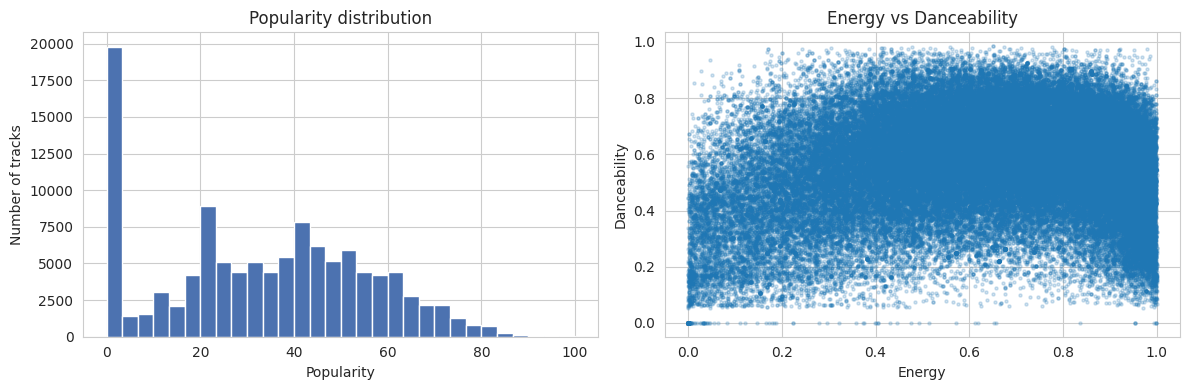

In [15]:
# subplots(1, 2) creates a figure with 1 row and 2 columns of plots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# HISTOGRAM: shows the distribution (spread/shape) of a single numeric column
axes[0].hist(df['popularity'], bins=30, color='#4C72B0')
axes[0].set_title('Popularity distribution')
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Number of tracks')

# SCATTER PLOT: shows the relationship between two numeric columns, one dot per row
# alpha=0.2 makes dots semi-transparent so dense overlapping areas look darker (a poor-man's density view)
axes[1].scatter(df['energy'], df['danceability'], alpha=0.2, s=5)
axes[1].set_title('Energy vs Danceability')
axes[1].set_xlabel('Energy')
axes[1].set_ylabel('Danceability')

plt.tight_layout()  # prevents titles/labels from overlapping between subplots
plt.show()

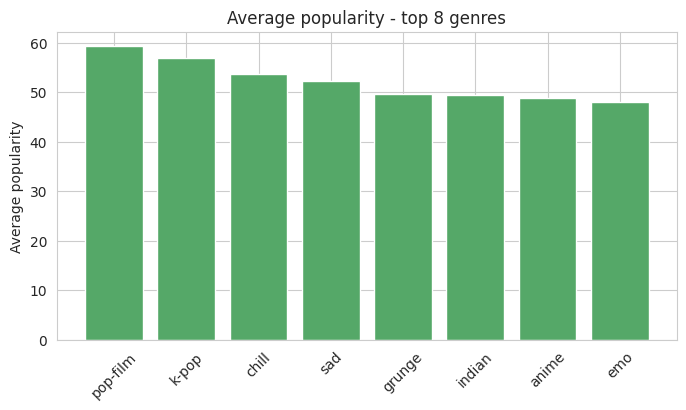

In [16]:
# BAR CHART: compares a value across categories - here, average popularity per top genre
top_genres = genre_avg_popularity.head(8)
plt.figure(figsize=(8, 4))
plt.bar(top_genres.index, top_genres.values, color='#55A868')
plt.xticks(rotation=45)  # rotates genre names so they don't overlap each other
plt.title('Average popularity - top 8 genres')
plt.ylabel('Average popularity')
plt.show()

### 6.2 Seaborn — distribution, box, pair plots, correlation heatmap

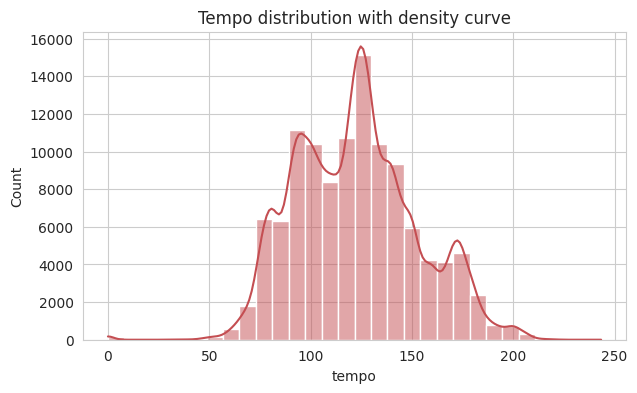

In [17]:
# sns.histplot with kde=True overlays a smooth density curve on top of the histogram bars
plt.figure(figsize=(7, 4))
sns.histplot(df['tempo'], bins=30, kde=True, color='#C44E52')
plt.title('Tempo distribution with density curve')
plt.show()

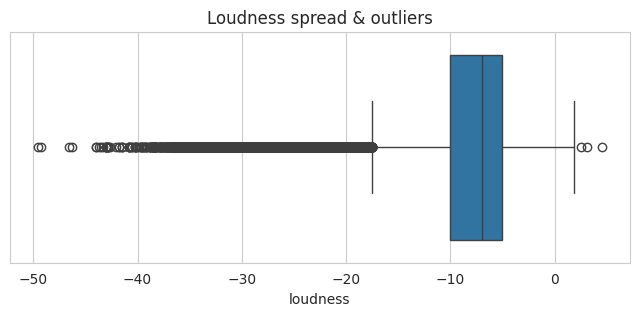

In [18]:
# BOX PLOT: shows median, quartiles, and OUTLIERS (dots beyond the whiskers) at a glance
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['loudness'])
plt.title('Loudness spread & outliers')
plt.show()

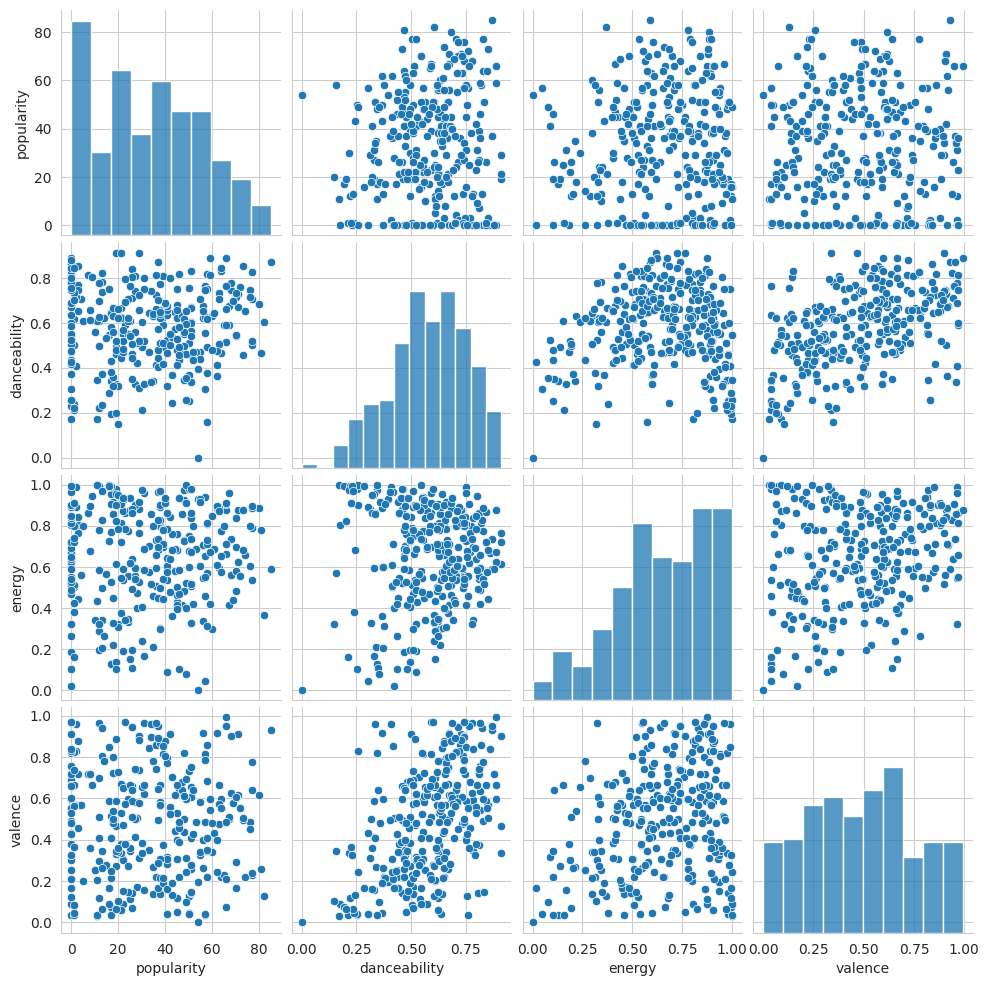

In [19]:
# PAIR PLOT: plots every numeric column against every other numeric column in a grid
# Useful to spot relationships across many columns at once - kept to a small sample so it renders quickly
# (this cell can take ~10-15 seconds to run - that's normal, not an error)
subset_cols = ['popularity', 'danceability', 'energy', 'valence']
sns.pairplot(df[subset_cols].sample(300, random_state=42))  # sample() takes 300 random rows for speed
plt.show()

In [ ]:
# CORRELATION HEATMAP: shows how strongly every numeric column relates to every other one
# .corr() computes correlation coefficients (-1 to 1); annot=True prints the actual number in each cell
numeric_cols = ['popularity', 'danceability', 'energy', 'loudness', 'tempo', 'valence']
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation heatmap')
plt.show()

## 7. EDA — reading what the plots just told us

Quick checklist we apply to every dataset:
- **Distributions** — is a column skewed, normal, or spread flat? (see the popularity/tempo histograms above)
- **Relationships** — do two columns move together? (see the energy vs danceability scatter, and the pairplot)
- **Correlation** — is there a strong numeric relationship worth noting? (see the heatmap — values close to +1 or -1 are strong)
- **Spotting issues** — outliers (box plot dots), skew (long histogram tail), or unexpected gaps

We'll now act on what EDA revealed: missing values, duplicates, and outliers need to be handled before this data can go into any model.

## 8. Data preprocessing — missing values, duplicates, outliers, cleaning

In [20]:
# .isnull() marks every cell True/False for missing, .sum() adds those up per column
# sort_values shows the columns with the MOST missing data first
df.isnull().sum().sort_values(ascending=False).head(10)

artists         1
album_name      1
track_name      1
track_id        0
popularity      0
duration_ms     0
explicit        0
danceability    0
energy          0
key             0
dtype: int64

In [22]:
# dropna(subset=[...]) removes only rows missing values in the LISTED columns (not the whole row for any missing value)
# We use this here because these 3 columns are core identifiers - a track with no name/artist isn't usable
df = df.dropna(subset=['artists', 'album_name', 'track_name'])
print('Remaining missing values across all columns:', df.isnull().sum().sum())

Remaining missing values across all columns: 0


In [23]:
# .duplicated() flags rows that are exact copies of an earlier row
print('Duplicate rows found:', df.duplicated().sum())

# drop_duplicates() removes them, keeping the first occurrence by default
df = df.drop_duplicates()

# reset_index(drop=True) renumbers rows 0,1,2,... cleanly after rows were removed above
# (without this, row numbers would have gaps where dropped rows used to be)
df = df.reset_index(drop=True)
print('Shape after removing duplicates:', df.shape)

Duplicate rows found: 450
Shape after removing duplicates: (113549, 20)


In [25]:
# OUTLIER DETECTION using the IQR (Interquartile Range) method
Q1 = df['tempo'].quantile(0.25)   # value below which 25% of the data falls
Q3 = df['tempo'].quantile(0.75)   # value below which 75% of the data falls
IQR = Q3 - Q1                     # the middle 50% spread of the data

# Anything beyond 1.5x the IQR past Q1/Q3 is treated as a statistical outlier - a widely used rule of thumb
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['tempo'] < lower_bound) | (df['tempo'] > upper_bound)]
print(f'Tempo outliers: {outliers.shape[0]} rows (normal range: {lower_bound:.1f} to {upper_bound:.1f})')

Tempo outliers: 615 rows (normal range: 38.1 to 201.2)


## 9. Encoding — turning category text into numbers

A model only understands numbers. If a column holds text categories (like `explicit: True/False` or `track_genre: pop/rock/jazz`), it must be converted first.

- **Label encoding** — assigns one integer per category (0, 1, 2...). Simple, but implies an order that may not exist — safest for binary or naturally-ordered categories.
- **One-hot encoding** — creates a separate 0/1 column per category. No false sense of order, but adds more columns. Best for nominal (unordered) categories.
- **Ordinal encoding** — like label encoding, but you deliberately choose the number-to-category mapping because a real order exists (e.g. low/medium/high -> 0/1/2).

In [27]:
# LABEL ENCODING example on a binary column
le = LabelEncoder()
# fit_transform() learns the categories present, then converts each row's text into an integer code
df['explicit_encoded'] = le.fit_transform(df['explicit'])

# .drop_duplicates() here just shows us the unique before/after mapping clearly
df[['explicit', 'explicit_encoded']].drop_duplicates()

,explicit,explicit_encoded
0,False,0
59,True,1


In [28]:
# ONE-HOT ENCODING example - each category becomes its own 0/1 column
top_genres = df['track_genre'].value_counts().head(5).index   # just the top 5 genres, to keep the table readable
sample = df[df['track_genre'].isin(top_genres)]                # keep only rows whose genre is in that top-5 list

# pd.get_dummies() converts one categorical column into multiple 0/1 columns, one per category
one_hot = pd.get_dummies(sample['track_genre'], prefix='genre')
one_hot.head()

,genre_acoustic,genre_british,genre_electronic,genre_emo,genre_funk
0,True,False,False,False,False
1,True,False,False,False,False
2,True,False,False,False,False
3,True,False,False,False,False
4,True,False,False,False,False


In [29]:
# ORDINAL ENCODING example - manual mapping because a genuine order exists
# (illustrative: turning a 3-level made-up 'energy_level' into 0/1/2, not from this dataset directly)
order_map = {'low': 0, 'medium': 1, 'high': 2}
demo_series = pd.Series(['low', 'high', 'medium', 'low'])
demo_series.map(order_map)   # .map() replaces each value using the dictionary we defined above

0    0
1    2
2    1
3    0
dtype: int64

## 10. Feature engineering & feature selection (brief intro)

- **Feature engineering** — creating new, more useful columns from existing ones (e.g. combining `danceability` and `energy` into a single `dance_energy_score`).
- **Feature selection** — deciding which columns actually help the model, and dropping the ones that add noise or are redundant (e.g. two columns that are almost perfectly correlated with each other, as seen in the heatmap).

In [30]:
# Simple feature engineering example: a new column combining two existing signals
df['dance_energy_score'] = (df['danceability'] + df['energy']) / 2
df[['danceability', 'energy', 'dance_energy_score']].head()

,danceability,energy,dance_energy_score
0,0.676,0.4610,0.5685
1,0.420,0.1660,0.2930
2,0.438,0.3590,0.3985
3,0.266,0.0596,0.1628
4,0.618,0.4430,0.5305


## 11. Imbalanced data — oversampling, undersampling, SMOTE (concept only, for now)

If a target column has, say, 95% of one class and 5% of another (e.g. 95% "not explicit" vs 5% "explicit"), a model can get 95% accuracy just by always predicting the majority class — while being useless at the minority class. Fixes:
- **Oversampling** — duplicate/synthesize more minority-class rows.
- **Undersampling** — remove some majority-class rows.
- **SMOTE** — Synthetic Minority Oversampling Technique: creates new, realistic synthetic minority examples instead of just copying existing ones.

We'll apply these hands-on once we reach classification problems from Day 9 onward.

In [31]:
# Checking for imbalance in our binary 'explicit' column, as a real example
df['explicit'].value_counts(normalize=True)  # normalize=True shows proportions instead of raw counts

explicit
False    0.914416
True     0.085584
Name: proportion, dtype: float64

## 12. Train/test split, validation set, cross-validation, data leakage (concept only, for now)

- **Train/test split** — train the model on one portion of data, test it on a portion it never saw, to check real performance.
- **Validation set** — a third portion, used while tuning the model, so the test set stays untouched until the very end.
- **Cross-validation** — instead of a single split, the data is split into k folds and the model is trained/tested k times on different folds, then scores are averaged for a more reliable estimate.
- **Data leakage** — when information from outside the training data (often accidentally from the test set) sneaks into training, making performance look better than it really is. Classic mistake: scaling the ENTIRE dataset before splitting into train/test — the scaler then "sees" test data statistics during training.

We'll use these for real starting Day 6, once we train our first model.

## 13. Scaling — standardization vs normalization, and why we convert to vectors

**Why convert data into vectors of numbers at all?** A trained model is really just a mathematical function. It cannot read "pop" or "True" — it needs pure numbers. Once every column is numeric (through encoding above), each row becomes a **vector** — literally a list of numbers like `[0.72, 0.65, -5.3, 120.4, 1]` — and that's exactly what gets fed into the model's math.

**Why scale before vectorizing?** If `loudness` ranges from -60 to 0 and `danceability` ranges from 0 to 1, a model that's sensitive to magnitude (like distance-based algorithms) will let `loudness` dominate purely because its numbers are bigger — not because it's actually more important. Scaling puts every feature on a comparable footing.

- **Standardization** (`StandardScaler`) — transforms values to mean 0, std 1. Best when data is roughly normal-shaped or has outliers.
- **Normalization** (`MinMaxScaler`) — squashes every value into a fixed [0, 1] range. Best when you need a strictly bounded range.

In [32]:
scale_cols = ['tempo', 'loudness', 'duration_ms']

# StandardScaler: (value - mean) / std  -> centers data around 0
standard_scaled = StandardScaler().fit_transform(df[scale_cols])

# MinMaxScaler: (value - min) / (max - min) -> squashes everything into [0, 1]
normalized_scaled = MinMaxScaler().fit_transform(df[scale_cols])

# Side-by-side comparison so the difference is visible on real numbers
comparison = pd.DataFrame({
    'tempo_raw': df['tempo'].values[:5],
    'tempo_standardized': standard_scaled[:5, 0],
    'tempo_normalized': normalized_scaled[:5, 0]
})
comparison

,tempo_raw,tempo_standardized,tempo_normalized
0,87.917,-1.142994,0.361245
1,77.489,-1.490909,0.318397
2,76.332,-1.529510,0.313643
3,181.740,1.987275,0.746758
4,119.949,-0.074292,0.492863


In [33]:
# FULL PIPELINE: encoded + scaled columns combined into final numeric feature vectors
feature_cols = ['popularity', 'danceability', 'energy', 'loudness', 'tempo', 'valence', 'explicit_encoded']
X = df[feature_cols].dropna()          # dropna() here ensures no missing values sneak into the math below
X_scaled = StandardScaler().fit_transform(X)   # scales all 7 columns together in one call

print('One track as a RAW feature vector (mixed scales, hard for a model to weigh fairly):')
print(X.iloc[0].values)

print('\nSame track as a SCALED feature vector (comparable scales - what actually gets fed to a model):')
print(X_scaled[0])

One track as a RAW feature vector (mixed scales, hard for a model to weigh fairly):
[73.     0.676  0.461 -6.746 87.917  0.715  0.   ]

Same track as a SCALED feature vector (comparable scales - what actually gets fed to a model):
[ 1.78047032  0.62839367 -0.72132759  0.29880036 -1.14299362  0.92898358
 -0.30593202]


## 14. Recap

Today we covered, hands-on:
- Kaggle environment: no drive mount, dataset attached via Add Input
- AI vs ML vs traditional programming, and the 4 types of ML (supervised/unsupervised = this course's focus)
- The ML pipeline: collection -> preprocessing -> EDA -> training -> evaluation -> deployment
- Library vs framework
- NumPy (arrays, indexing, reshaping, broadcasting, aggregations)
- Pandas (Series/DataFrame, loc/iloc, filtering, groupby, merge)
- Matplotlib & Seaborn (histograms, scatter, bar, box, pair plots, heatmaps)
- EDA: distributions, relationships, correlation, spotting issues
- Data types, features vs target
- Cleaning: missing values, duplicates, outliers
- Encoding: label, one-hot, ordinal
- Feature engineering & selection (intro)
- Imbalanced data concepts: oversampling, undersampling, SMOTE
- Train/test split, validation, cross-validation, data leakage (concepts)
- Scaling: standardization vs normalization, and why rows become vectors

---

## Assignment

Using this same Spotify dataset:

1. Load it the Kaggle way (no drive mount, no manual download) — confirm the path with `os.walk()` like we did above.
2. Produce a full EDA: at least **4 different plots** (histogram, boxplot, scatter, heatmap), each followed by a 1-line written observation in a markdown cell.
3. Handle missing values with a justified strategy (drop vs impute) — explain your choice in a markdown cell.
4. Encode **one** categorical column with label encoding **and** one-hot encoding — explain in a markdown cell when you'd pick each.
5. Scale at least 2 numeric columns with both `StandardScaler` and `MinMaxScaler`, and compare the outputs side by side.
6. Print one final row as a fully preprocessed numeric vector, ready for a model, and explain in one sentence what each number in it represents.

**Bonus:** use the IQR method to find outliers in a column of your choice, and decide (with written reasoning) whether to keep, cap, or remove them.
